Importing necessary libraries

In [52]:
import numpy as np
from typing import Union, Callable
import matplotlib.pyplot as plt
import pandas as pd

## **Question 1** ##

**Part (a)**

Defining functions

In [89]:
Scalar = Union[float, np.ndarray]

# RK4
def rk4(
    f: Callable[[float, Scalar], Scalar],
    x: float,
    y: Scalar,
    h: float,
) -> Scalar:
    """
    Advance one step using classical fourth-order Runge-Kutta.

    Parameters:
        f: Callable derivative function f(x, y).
        x: Current x value.
        y: Current y value (can be scalar or array-like).
        h: Step size.

    Returns:
        Estimated y value at x + h.
    """
    k1 = f(x, y)
    k2 = f(x + h/2, y + h*k1/2)
    k3 = f(x + h/2, y + h*k2/2)
    k4 = f(x + h, y + h*k3)

    return y + h*(k1 + 2*k2 + 2*k3 + k4)/6

# Function for calling RK4 method
def caller_rk4(
    f: Callable[[float, Scalar], np.ndarray],
    xs: np.ndarray,
    y0: np.ndarray,
    N: int,
    h: float
) -> np.ndarray:
    """
    Generate solution values by repeatedly applying RK4 method.

    Parameters:
        f: Callable derivative function f(x, y).
        xs: Array of x values to step through.
        y0: Initial y value (array-like).
        N: Number of steps/points to compute.
        h: Step size.

    Returns:
        Array of y values with shape (N, len(y0)).
    """
    y = y0
    ys = np.zeros((N, len(y0)))

    for i in range(N):
        x = xs[i]
        ys[i, :] = y
        y = rk4(f, x, y, h)
    
    return ys


We define 2 variables as follows:

$y_0 = y$

$y_1 = \frac{dy_0}{dx}$
    
The given equation can be decomposed into two 1st order equations as follows:

\begin{equation}
    \frac{dy_0}{dx} = y_1
\end{equation}

\begin{equation}
    \frac{dy_1}{dx} = \mu(1-y_0^2)y_1 - \lambda y_0
\end{equation}

The 2 equations can be combined and written in matrix form as:

\begin{equation}
    \frac{d}{dx}
    \begin{bmatrix}
        y_0 \\
        y_1
    \end{bmatrix} =
    \begin{bmatrix}
        y_1 \\
        \mu(1 - y_0^2)y_1 - \lambda y_0
    \end{bmatrix}
\end{equation}


Defining parameters and derivative function for RK4

In [90]:
# Derivative function for RK4
def f(x, y):
    global mu, l
    return np.asarray([y[1], mu*(1-y[0]**2)*y[1] - l*y[0]])

# Parameters
h = 1e-4
mu = 5
l = 40  # lambda
ti, tf = 0, 20
Y0rk4 = np.array([0.5, 0.0])   # Initial condition vector

# Calculating N and xs
N = int((tf - ti)/h) + 1
tsrk4 = ti + h*np.arange(N)

Solving the system of equations

In [91]:
Ysrk4 = caller_rk4(f, tsrk4, Y0rk4, N, h)    # RK4 solution vector
ysrk4, vsrk4 = Ysrk4[:, 0], Ysrk4[:, 1]     # Position and velocity

Visualising Data through pandas Dataframe

In [92]:
dfrk4 = pd.DataFrame(Ysrk4, columns = ["Position", "Velocity"])
print("Time steps:", len(dfrk4))
dfrk4.head()

Time steps: 200001


,Position,Velocity
0,0.500000,0.000000
1,0.500000,-0.002000
2,0.500000,-0.004001
3,0.499999,-0.006003
4,0.499998,-0.008006


Plotting the solution

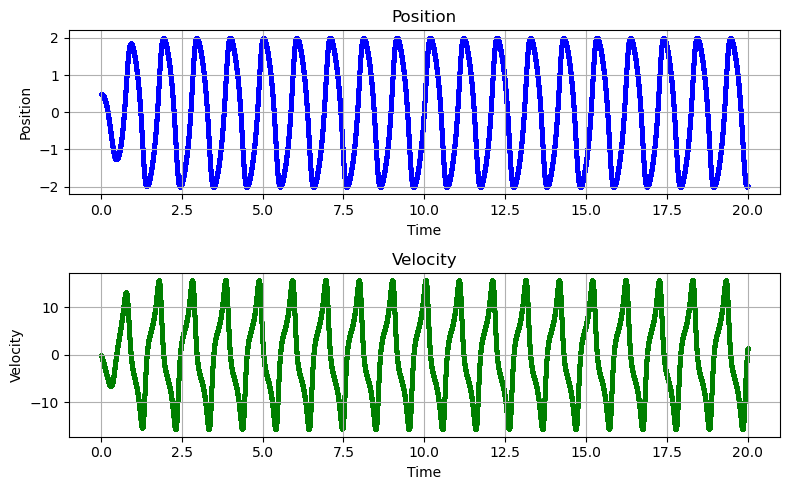

In [ ]:
plt.figure(figsize=(8, 5))

# Position
plt.subplot(2, 1, 1)
plt.scatter(tsrk4, ysrk4, color="blue", s=4)
plt.xlabel("Time")
plt.ylabel("Position")
plt.title("Position")
plt.grid()

# Velocity
plt.subplot(2, 1, 2)
plt.scatter(tsrk4, vsrk4, color="green", s=4)
plt.xlabel("Time")
plt.ylabel("Velocity")
plt.title("Velocity")
plt.grid()

plt.tight_layout()
plt.show()

**Part (b)**

Defining the Butcher Tableau for Dormand Prince

In [64]:
# Dormand-Prince in matrix form
a = [0.2, 0.3, 0.8, 8/9, 1.0, 1.0]
b = [
    [1/5, 0, 0, 0, 0, 0],
    [3/40, 9/40, 0, 0, 0, 0],
    [44/45, -56/15, 32/9, 0, 0, 0],
    [19372/6561, -25360/2187, 64448/6561, -212/729, 0, 0],
    [9017/3168, -355/33, 46732/5247, 49/176, -5103/18656, 0],
    [35/384, 0, 500/1113, 125/192, -2187/6784, 11/84]
]
c = [35/384, 0, 500/1113, 125/192, -2187/6784, 11/84, 0]

# Dormand-Prince
a2 = 1/5;  b21 = 1/5;
a3 = 3/10; b31 = 3/40;       b32 = 9/40;
a4 = 4/5;  b41 = 44/45;      b42 = -56/15;      b43 = 32/9;
a5 = 8/9;  b51 = 19372/6561; b52 = -25360/2187; b53 = 64448/6561; b54 =-212/729;
a6 = 1;    b61 = 9017/3168;  b62 = -355/33;     b63 = 46732/5247; b64 = 49/176;  b65 = -5103/18656;
a7 = 1;    b71 = 35/384;     b72 = 0;           b73 = 500/1113;   b74 = 125/192; b75 = -2187/6784;  b76 = 11/84;

c1 = 35/384; c2 = 0; c3 = 500/1113; c4 = 125/192; c5=-2187/6784; c6 = 11/84; c7 = 0;
c1s = 5179/57600; c2s = 0; c3s = 7571/16695; c4s = 393/640; c5s = -92097/339200; c6s = 187/2100; c7s = 1/40;

Defining functions

In [106]:
# Predictor-Corrector
# Embedded Runge-Kutta formulas
def erk54h(f, x, y, h, k7bh):
    # Implement FSAL (first same as last)
    # The first k1 = k7bh, unless k1 is zero (initially)
    if sum(k7bh) == 0: 
        k1 = h*f(x, y)
    else:
        k1 = k7bh*h

    # Implement rest of the Butcher table
    k2 = h*f(x + a2*h, y + b21*k1)
    k3 = h*f(x + a3*h, y + b31*k1 + b32*k2)
    k4 = h*f(x + a4*h, y + b41*k1 + b42*k2 + b43*k3)
    k5 = h*f(x + a5*h, y + b51*k1 + b52*k2 + b53*k3 + b54*k4)
    k6 = h*f(x + a6*h, y + b61*k1 + b62*k2 + b63*k3 + b64*k4 + b65*k5)

    # get y fifth-order correct
    y5 = y + c1*k1 + c2*k2 + c3*k3 + c4*k4 + c5*k5 + c6*k6 # c7 = 0     
    
    # FSAL -> the last
    k7bh = f(x + a7*h, y5)

    # get y fourth-order correct
    y4 = y + c1s*k1 + c2s*k2 + c3s*k3 + c4s*k4 + c5s*k5 + c6s*k6 + c7s*k7bh*h

    # return y, error, k7bh
    err = abs(y5 - y4)
    return y5, err, k7bh

# Caller for Embedded RK method
def caller54(fn, y_ini, x0, xT, h0, max_iter, abstol, reltol):
    # Initialising arrays for storing values
    ys = np.zeros((max_iter, len(y_ini)))
    xs = np.zeros((max_iter, 1))

    # Initialising parameters
    h = h0
    y = np.asarray(y_ini)
    xs[0] = x0
    ys[0, :] = y
    x = x0; i = 0; k = 1
    k7bh = np.zeros(len(y_ini))

    # Evolving the system
    while x<=xT and i<max_iter-1:
        tol = abstol + reltol*np.linalg.norm(ys[i,:])   # calculate the tolerance
        y, err, k7bh = erk54h(fn, xs[i], ys[i], h, k7bh)     # get the next y and the error
        merr = np.max(err)      # get max error

        # Ensures zero division does not happen while calculating hnew
        if merr == 0.0: 
            merr = tol/100

        hnew = 0.9*h*(tol/merr)**0.2
        
        # If the step is valid (less error than tol) then we proceed
        if merr<tol and h/5<hnew<5*h:  
            x += h
            i += 1
            xs[i] = x
            ys[i,:] = y 
            
        h = hnew    # Updating h
    
    # if the maximum number of steps exceeded
    if i>=max_iter-1:
        print(i," Increase max_iter.")
        return None
    
    # return the usable portion of the array
    return xs[:i+1], ys[:i+1,:]


Defining parameters and solving the equations

In [107]:
abstol = 1e-6
reltol = 1e-8
max_iter = 20000
h0 = 1e-4
ti, tf = 0, 20
Y0dp = np.array([0.5, 0.0])

X = caller54(f, Y0dp, ti, tf, h0, max_iter, abstol, reltol)    # Calling the solver

if X is None:
    pass
else:
    tsdp, Ysdp = X      # Unpacking values
    ysdp, vsdp = Ysdp[:, 0], Ysdp[:, 1]

Visualising data through pandas Dataframe

In [108]:
dfdp = pd.DataFrame(Ysdp, columns=["Position", "Velocity"])
print("Time Steps:", len(dfdp))
dfdp.head()

Time Steps: 17146


,Position,Velocity
0,0.500000,0.000000
1,0.499212,-0.179316
2,0.494970,-0.460065
3,0.451034,-1.495838
4,0.355438,-2.650265


Plotting the solutions

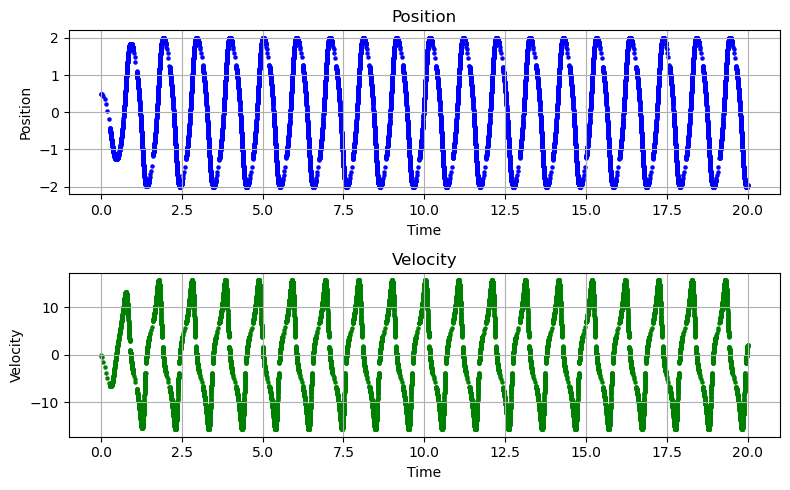

In [109]:
plt.figure(figsize=(8, 5))

# Position
plt.subplot(2, 1, 1)
plt.scatter(tsdp, ysdp, color = "blue", s=5)
plt.xlabel("Time")
plt.ylabel("Position")
plt.title("Position")
plt.grid()

# Velocity
plt.subplot(2, 1, 2)
plt.scatter(tsdp, vsdp, color = "green", s=5)
plt.xlabel("Time")
plt.ylabel("Velocity")
plt.title("Velocity")
plt.grid()

plt.tight_layout()
plt.show()

**Part (c)**

Plotting phase-space trajectory (y' versus y)

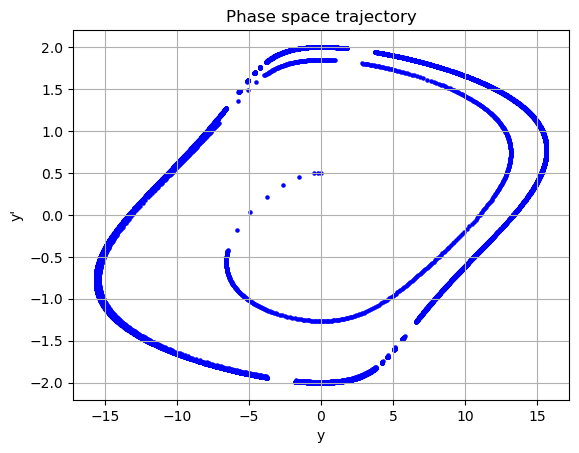

In [110]:
plt.scatter(vsdp, ysdp, color = "blue", s = 5)
plt.xlabel("y")
plt.ylabel("y'")
plt.title("Phase space trajectory")

plt.grid()
plt.show()